In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
import seaborn as sns
from sdv.metadata import Metadata
from sdv.single_table import TVAESynthesizer

np.random.seed(29)

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [4]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1, random_state=29).reset_index(drop=True)

In [5]:
len(df)

18000

In [6]:
model_hardening_data = df.head(6000)
intercepted_data = df.tail(12000)

In [7]:
model_hardening_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid2,186.0,10.0,150.0,350.0,167.0,167.0,166.0
1,rpi-4a,16.2,17.4,1446.0,17.8,435.5,17.1,19.3
2,odroid1,165.0,167.0,167.0,168.0,169.0,166.0,168.0
3,odroid4,169.0,175.0,176.0,174.0,174.0,173.0,173.0
4,rpi-8c,24.9,629.1,16.7,2092.1,16.1,17.3,17.6
...,...,...,...,...,...,...,...,...
5995,odroid1,166.0,170.0,167.0,169.0,166.0,168.0,168.0
5996,odroid2,180.0,172.0,156.0,172.0,170.0,12.0,166.0
5997,odroid4,170.0,175.0,175.0,173.0,174.0,175.0,173.0
5998,rpi-4a,620.7,400.1,19.8,18.2,21.0,18.9,19.9


In [8]:
intercepted_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
6000,odroid4,173.0,172.0,174.0,174.0,171.0,172.0,173.0
6001,odroid3,165.0,167.0,168.0,166.0,167.0,167.0,164.0
6002,odroid4,170.0,174.0,173.0,173.0,174.0,173.0,171.0
6003,rpi-8d,16.1,17.8,17.4,781.8,17.6,19.1,19.1
6004,odroid4,172.0,173.0,175.0,174.0,174.0,174.0,175.0
...,...,...,...,...,...,...,...,...
17995,rpi-8a,230.7,231.9,433.3,16.6,232.2,233.2,433.4
17996,odroid1,166.0,169.0,168.0,167.0,168.0,167.0,169.0
17997,odroid1,329.0,169.0,168.0,168.0,167.0,167.0,168.0
17998,rpi-8a,416.6,229.9,16.2,216.5,416.5,233.2,433.5


In [9]:
predictor = TabularPredictor.load("../models/classification")

In [10]:
metadata = Metadata.detect_from_dataframe(
    data=intercepted_data,
    table_name='intercepted_data')

# Which epoch performs the best?

### This takes a very long time (1hr with an RTX A5000), make sure you have a GPU or adjust epoch interals

In [11]:
vae_results = pd.DataFrame(columns=['epoch', 'accuracy', 'balanced_accuracy', 'mcc'])

for i in range(100,2000,100):
    print(i)
    synthesizer = TVAESynthesizer(
        metadata, 
        epochs=i
    )
    
    synthesizer.fit(intercepted_data)
    synthetic_data = synthesizer.sample(num_rows=1000)
    
    y_pred = predictor.predict(synthetic_data)
    y_pred_proba = predictor.predict_proba(synthetic_data)
    results = predictor.evaluate(synthetic_data)
    
    new_results = {'epoch':i, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    vae_results.loc[len(vae_results)] = (new_results)

100


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:104: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.

  File "c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\zac\miniconda3\envs\iot_gpu\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\zac\miniconda3\envs\iot_gpu\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\zac\miniconda3\envs\iot_gpu\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


200
300
400
500
600
700
800
900
1000


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



1100
1200
1300
1400
1500
1600
1700
1800
1900


# Epoch 1300 is able to fool our classification model most often

<Axes: xlabel='epoch', ylabel='value'>

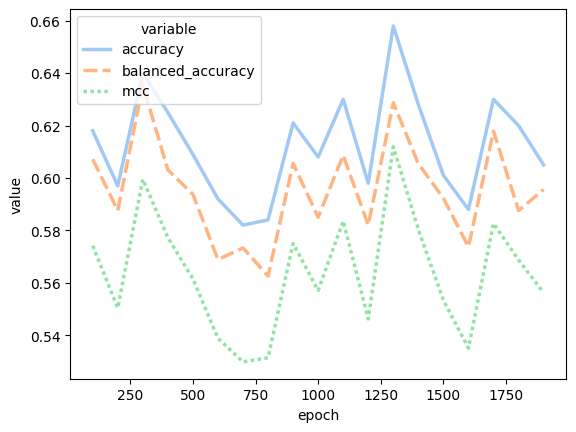

In [12]:
sns.lineplot(data=pd.melt(vae_results, ['epoch']), x='epoch', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [14]:
synthesizer = TVAESynthesizer(
    metadata, 
    epochs=1300
)

synthesizer.fit(intercepted_data)
synthetic_impersonation_data = synthesizer.sample(num_rows=1500)

## Which devices are most vulnerable to this attack?

In [15]:
devices_fooled = pd.DataFrame(columns=['device', 'accuracy'])
for device in list(y_pred.unique()):
    devices_fooled.loc[len(devices_fooled)] = {'device': device, 'accuracy': 0.0}

for pred, label in zip(list(y_pred), list(synthetic_impersonation_data['label'])):
    if pred == label:
        devices_fooled.loc[devices_fooled['device'] == pred, 'accuracy'] += 1

for device in list(y_pred.unique()):
    devices_fooled.loc[devices_fooled['device'] == device, 'accuracy'] /= list(synthetic_impersonation_data['label']).count(device)

devices_fooled['accuracy'] *= 100

<Axes: xlabel='device', ylabel='accuracy'>

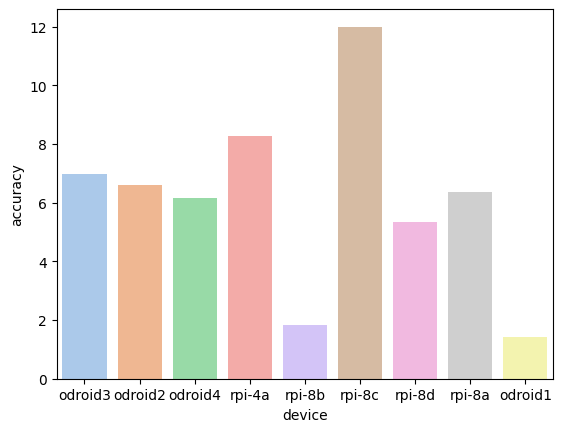

In [16]:
sns.barplot(data=devices_fooled, x='device', y='accuracy', hue='device', palette="pastel", legend=False, linewidth=2.5)

# Training an impersonation detection model

## Training Data

### Impersonator

In [18]:
# Let's say we use the same epoch as our adversary, and assume it's also the best epoch for our smaller dataset.
# However, we train the synthesizer on our train data ONLY.
# train and test data are used to train separate synthesizer models.
impersonator_training = pd.DataFrame()

synthesizer = TVAESynthesizer(
    metadata, 
    epochs=1300
)

# Train the synthetic model using 75% of a train data. Holdout the rest for eval
synthesizer.fit(model_hardening_data.head(4500))
impersonator_training = pd.concat([impersonator_training, synthesizer.sample(4500)])

In [19]:
impersonator_training['label'] = 'impersonator'

### Genuine

In [21]:
genuine_training = model_hardening_data.head(4500).copy(deep=True)
genuine_training['label'] = 'genuine'

<Axes: >

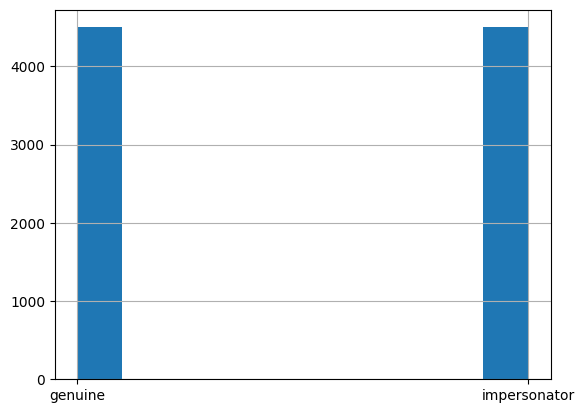

In [22]:
combined_training = pd.concat([genuine_training, impersonator_training])
combined_training = combined_training.sample(frac=1)
combined_training['label'].hist()

In [23]:
combined_training.to_csv('vae_impersonation_training.csv')

## Testing

### Impersonator

In [24]:
impersonator_testing = synthetic_impersonation_data.copy(deep=True)
impersonator_testing['label'] = 'impersonator'

### Genuine

In [25]:
genuine_testing = model_hardening_data.tail(1500).copy(deep=True)
genuine_testing['label'] = 'genuine'

<Axes: >

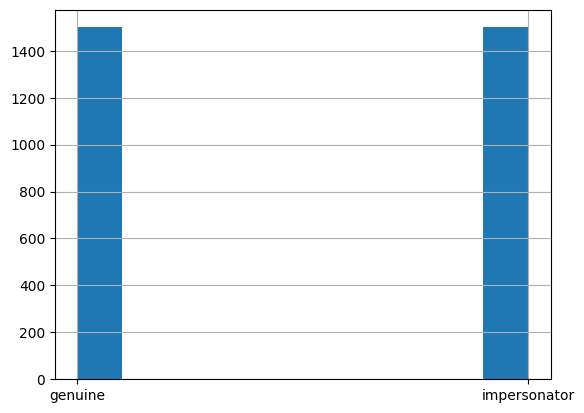

In [26]:
combined_testing = pd.concat([genuine_testing, impersonator_testing])
combined_testing['label'].hist()

In [27]:
combined_testing.to_csv('vae_impersonation_testing.csv')

## Training the model

In [28]:
results_df = pd.DataFrame(columns=['data_amount', 'accuracy', 'balanced_accuracy', 'mcc'])

# How much data do we need to accurately detect an impersonator?
for data_amount in range(1000, 9000, 1000):
    print(f'Amount of data: {data_amount}')

    impersonation_detector = TabularPredictor(label='label').fit(combined_training[:data_amount], num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)
    
    y_pred = impersonation_detector.predict(combined_testing)
    y_pred_proba = impersonation_detector.predict_proba(combined_testing)
    results = impersonation_detector.evaluate(combined_testing)

    new_results = {'data_amount':data_amount, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    results_df.loc[len(results_df)] = (new_results)

No path specified. Models will be saved in: "AutogluonModels\ag-20250328_044630"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       49.01 GB / 63.72 GB (76.9%)
Disk Space Avail:   962.43 GB / 1906.98 GB (50.5%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Spoofing Attack Detection\AutogluonModels\ag-20250328_044630"
Train Data Rows:    1000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['genuine', 'impersonator']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may

Amount of data: 1000
[1000]	valid_set's binary_error: 0.225


	0.79	 = Validation score   (accuracy)
	2.07s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.825	 = Validation score   (accuracy)
	1.57s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.825	 = Validation score   (accuracy)
	0.33s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.83	 = Validation score   (accuracy)
	0.31s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.79	 = Validation score   (accuracy)
	0.31

Amount of data: 2000
[1000]	valid_set's binary_error: 0.185
[2000]	valid_set's binary_error: 0.155


	0.845	 = Validation score   (accuracy)
	6.56s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9025	 = Validation score   (accuracy)
	2.75s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8725	 = Validation score   (accuracy)
	0.35s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.86	 = Validation score   (accuracy)
	0.33s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.8275	 = Validation score   (accuracy)


...

	0.9367	 = Validation score   (accuracy)
	11.88s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.95	 = Validation score   (accuracy)
	2.43s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.935	 = Validation score   (accuracy)
	0.4s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9333	 = Validation score   (accuracy)
	0.4s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9	 = Validation score   (accuracy)
	0.3

Amount of data: 7000
[1000]	valid_set's binary_error: 0.0885714
[2000]	valid_set's binary_error: 0.0714286
[3000]	valid_set's binary_error: 0.0585714


	0.9471	 = Validation score   (accuracy)
	16.58s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9529	 = Validation score   (accuracy)
	2.74s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9429	 = Validation score   (accuracy)
	0.42s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.95	 = Validation score   (accuracy)
	0.41s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.92	 = Validation score   (accuracy)


Amount of data: 8000
[1000]	valid_set's binary_error: 0.0925


	0.9087	 = Validation score   (accuracy)
	4.31s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.955	 = Validation score   (accuracy)
	2.22s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.94	 = Validation score   (accuracy)
	0.44s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9425	 = Validation score   (accuracy)
	0.43s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9163	 = Validation score   (accuracy)


In [29]:
impersonation_detector.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMLarge,0.95875,accuracy,0.008238,14.923497,0.008238,14.923497,1,True,12
1,LightGBM,0.95500,accuracy,0.015853,2.217949,0.015853,2.217949,1,True,4
2,XGBoost,0.95000,accuracy,0.007261,1.485038,0.007261,1.485038,1,True,10
3,RandomForestEntr,0.94250,accuracy,0.044077,0.428682,0.044077,0.428682,1,True,6
4,RandomForestGini,0.94000,accuracy,0.043946,0.438660,0.043946,0.438660,1,True,5
5,ExtraTreesGini,0.91625,accuracy,0.044310,0.373906,0.044310,0.373906,1,True,7
6,ExtraTreesEntr,0.91125,accuracy,0.043398,0.353332,0.043398,0.353332,1,True,8
7,LightGBMXT,0.90875,accuracy,0.018939,4.305862,0.018939,4.305862,1,True,3
8,NeuralNetTorch,0.83250,accuracy,0.000000,43.240897,0.000000,43.240897,1,True,11
9,KNeighborsDist,0.81000,accuracy,0.031396,0.000000,0.031396,0.000000,1,True,2


In [30]:
results_df

,data_amount,accuracy,balanced_accuracy,mcc
0,1000,0.833333,0.833333,0.667068
1,2000,0.877333,0.877333,0.756487
2,3000,0.873333,0.873333,0.747840
3,4000,0.896333,0.896333,0.795258
4,5000,0.906000,0.906000,0.814035
5,6000,0.901667,0.901667,0.805385
6,7000,0.908000,0.908000,0.818537
7,8000,0.911000,0.911000,0.824599


# 5000 genuine/impersonator rows gives almost 90% acc

<Axes: xlabel='data_amount', ylabel='value'>

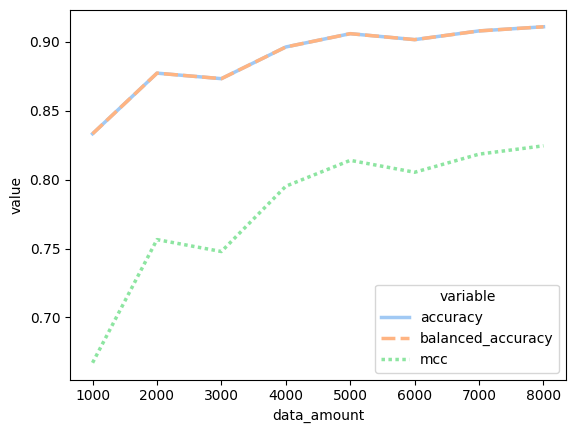

In [31]:
sns.lineplot(data=pd.melt(results_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)